# Proyecto de Grado: IA al servicio de las comunidades
Maestría en Analítica para la Inteligencia de Negocios

**Nombres:** María Fernanda Izquierdo Aparicio & Ana María Ochoa Muñoz

**Fecha:** 4 de Mayo de 2025

Este modelo forma parte del proyecto de grado de la Maestría en Analítica para la Inteligencia de Negocios de la Pontificia Universidad Javeriana, enfocado en la aplicación de Inteligencia Artificial al servicio de las comunidades. Su objetivo es clasificar imágenes de plantas en función de su especie usando una arquitectura pre-entrenada RESNET

## 1. Importe de Librerias

In [3]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import os
import zipfile
import shutil
import seaborn as sns
import datetime
import cv2

import keras
from keras import models
from keras import layers

import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import Layer
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report

from PIL import Image  # Librería para abrir y manipular imágenes

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

In [4]:
#Medir_tiempo_ejecucion():
inicio = datetime.datetime.now()
print(f"Inicio: {inicio.strftime('%Y-%m-%d %H:%M:%S.%f')}")

Inicio: 2025-05-11 18:44:57.095249


## 2. Definción de Rutas y Parámetros

In [6]:
data_dir = 'Datos Finales Enfermedad Balanceados'  # Reemplaza con la ruta real
metadata_file = 'archivos_datos_balanceados_enfermedad.csv' # Reemplaza con la ruta real
image_height = 150
image_width = 150
batch_size = 15
num_classes = None  # Se determinará automáticamente del archivo CSV

## 3. Cargar y procesar los metadatos

In [15]:
try:
    metadata = pd.read_csv(metadata_file, sep=";")
    metadata["Planta_Condición_Enfermedad"] = metadata["Planta_Estado_Español"] + "_" + metadata["Nombre Coloquial en Colombia"]
    metadata = metadata.rename(columns={'Nombre del archivo': 'image_id'})
    
    # Asegúrate de que las columnas 'filename' (o el nombre de tu columna de nombres de archivo)
    # y 'label' (o el nombre de tu columna de etiquetas) existan.
   
    if 'image_id' not in metadata.columns or 'Planta_Condición_Enfermedad' not in metadata.columns:
        raise ValueError("El archivo CSV debe contener las columnas 'image_id' y 'Planta'.")
    class_names = metadata['Planta_Condición_Enfermedad'].unique().tolist()
    num_classes = len(class_names)
    print(f"Se encontraron {num_classes} clases: {class_names}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo de metadatos en '{metadata_file}'.")
    exit()
except ValueError as e:
    print(f"Error al procesar el archivo CSV: {e}")
    exit()

Se encontraron 37 clases: ['Fresa_Saludable_Saludable', 'Coliflor_Enferma_Podredumbre blanda', 'Papa_Enferma_Quemado de la papa', 'Maíz_Saludable_Saludable', 'Tomate_Enferma_Pinta en ojo de buey', 'Papa_Enferma_Pudrición de la papa', 'Tomate_Enferma_Pudrición de la papa', 'Tomate_Enferma_Moteado del tomate', 'Yuca_Enferma_Venas marrones de la yuca', 'Tomate_Enferma_Hongo blanco del tomate', 'Coliflor_Saludable_Saludable', 'Manzana_Enferma_Hongo del manzano', 'Tomate_Enferma_Puntos negros del tomate', 'Yuca_Enferma_Pudrición de la yuca', 'Yuca_Enferma_Manchas verdes en la yuca', 'Tomate_Enferma_Quemado de la papa', 'Maíz_Enferma_Moho rojo del maíz', 'Pepino Cohombro_Saludable_Saludable', 'Tomate_Saludable_Saludable', 'Yuca_Saludable_Saludable', 'Coliflor_Enferma_Pudrición del fruto', 'Tomate_Enferma_Hojas enrolladas del tomate', 'Manzana_Enferma_Costra de la manzana', 'Maíz_Enferma_Quemazón del maíz', 'Fríjol_Saludable_Saludable', 'Tomate_Enferma_Polvillo rojo', 'Fríjol_Enferma_Mancha a

In [17]:
train, test= train_test_split(metadata, test_size=0.2, random_state=42,shuffle=True, stratify=metadata['Planta_Condición_Enfermedad'])
train.shape, test.shape

((8880, 12), (2220, 12))

In [19]:
train.Planta_Condición_Enfermedad.value_counts()

Planta_Condición_Enfermedad
Tomate_Enferma_Pinta en ojo de buey              240
Tomate_Saludable_Saludable                       240
Maíz_Enferma_Quemazón del maíz                   240
Tomate_Enferma_Moteado del tomate                240
Manzana_Enferma_Pudrición del fruto              240
Coliflor_Enferma_Moho azu                        240
Fresa_Saludable_Saludable                        240
Papa_Enferma_Pudrición de la papa                240
Tomate_Enferma_Hongo blanco del tomate           240
Papa_Enferma_Quemado de la papa                  240
Yuca_Saludable_Saludable                         240
Fríjol_Enferma_Oxido de frijol                   240
Pepino Cohombro_Saludable_Saludable              240
Tomate_Enferma_Polvillo rojo                     240
Fríjol_Saludable_Saludable                       240
Yuca_Enferma_Manchas verdes en la yuca           240
Tomate_Enferma_Puntitos marrones en las hojas    240
Tomate_Enferma_Puntos negros del tomate          240
Manzana_Enferma_Co

## 4. Crear un generador de datos

### 4.1. Sin Pre-processing Function

In [23]:
train.Planta_Condición_Enfermedad = train.Planta_Condición_Enfermedad.astype('str')

datagen = ImageDataGenerator(
    validation_split = 0.2,
    #preprocessing_function = preprocess_leaf_image,
    rotation_range = 45,
    zoom_range = 0.2,
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = 'nearest',
    shear_range = 0.1,
    height_shift_range = 0.1,
    width_shift_range = 0.1
)

train_generator = datagen.flow_from_dataframe(
    dataframe=train,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Condición_Enfermedad',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',  # Importante para clasificación multiclase
    subset='training',
    seed=42,
    classes=class_names  # Asegurarse del orden de las clases
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=train,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Condición_Enfermedad',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42,
    classes=class_names
)

Found 7104 validated image filenames belonging to 37 classes.
Found 1775 validated image filenames belonging to 37 classes.


In [25]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def mostrar_histograma_h(img):
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)
    
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img_resized = cv2.resize(img_bgr, (512, 512), interpolation=cv2.INTER_CUBIC)
    hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    plt.figure(figsize=(10, 4))
    plt.hist(h.ravel(), bins=180, range=[0, 180], color='g', alpha=0.8)
    plt.title('Histograma del canal Hue')
    plt.xlabel('Valor de Hue (0-180)')
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.show()

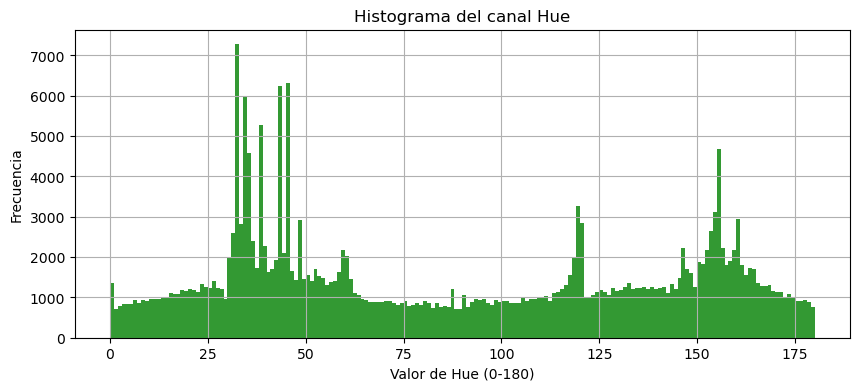

In [27]:
images, labels = next(train_generator)
mostrar_histograma_h(images[0])

In [29]:
# Obtener un lote de imágenes aumentadas
images, labels = next(train_generator)

# Mostrar las primeras 9 imágenes del lote
plt.figure(figsize=(50, 50))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].astype("uint8"))
    plt.title(f"Clase: {train_generator.class_indices}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### 4.2. Con Pre-processing Function

In [31]:
def preprocess_leaf_image(img):
    # 1. Asegurarse que img esté en el rango [0,255] y tipo uint8
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)

    # 2. Convertir de RGB (usado por Keras) a BGR (usado por OpenCV)
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # 3. Redimensionar a 512x512
    img_resized = cv2.resize(img_bgr, (150, 150), interpolation=cv2.INTER_CUBIC)

    # 4. Convertir a HSV
    hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)

    # 5. Definir el rango de verde (ajustable)
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([85, 255, 255])
    mask = cv2.inRange(hsv, lower_green, upper_green)

    # Validar si la máscara tiene suficientes píxeles activados
    green_ratio = np.sum(mask > 0) / (mask.shape[0] * mask.shape[1])
    if green_ratio < 0.01:
        # Si no hay suficiente verde, saltar segmentación
        segmented = img_resized
    else:
        segmented = cv2.bitwise_and(img_resized, img_resized, mask=mask)

    # 6. Convertir a LAB para aplicar CLAHE
    lab = cv2.cvtColor(segmented, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l_clahe = clahe.apply(l)

    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    # 7. Filtro bilateral
    img_filtered = cv2.bilateralFilter(img_clahe, d=9, sigmaColor=75, sigmaSpace=75)

    # 8. Convertir de nuevo a RGB
    img_rgb = cv2.cvtColor(img_filtered, cv2.COLOR_BGR2RGB)

    # 9. Normalizar a [0,1]
    return img_rgb.astype(np.float32) / 255.0


In [32]:
train.Planta_Condición_Enfermedad = train.Planta_Condición_Enfermedad.astype('str')

datagen = ImageDataGenerator(
    validation_split = 0.2,
    preprocessing_function = preprocess_leaf_image,
    rotation_range = 45,
    zoom_range = 0.2,
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = 'nearest',
    shear_range = 0.1,
    height_shift_range = 0.1,
    width_shift_range = 0.1
)

train_generator = datagen.flow_from_dataframe(
    dataframe=train,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Condición_Enfermedad',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',  # Importante para clasificación multiclase
    subset='training',
    seed=42,
    classes=class_names  # Asegurarse del orden de las clases
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=train,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Condición_Enfermedad',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42,
    classes=class_names
)

Found 7104 validated image filenames belonging to 37 classes.
Found 1775 validated image filenames belonging to 37 classes.


In [33]:
# Obtener un lote de imágenes aumentadas
images, labels = next(train_generator)

# Mostrar las primeras 9 imágenes del lote
plt.figure(figsize=(50, 50))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].astype("uint8"))
    plt.title(f"Clase: {train_generator.class_indices}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Cargar el modelo ResNet50 preentrenado (sin la capa superior de clasificación)

In [39]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(image_height, image_width, 3))

## 6. Congelar las capas convolucionales base

In [42]:
for layer in base_model.layers:
    layer.trainable = False

## 7. Añadir una nueva capa de clasificación personalizada

In [45]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
# Puedes añadir más capas densas aquí si lo deseas
# x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

## 8. Crear el modelo final

In [48]:
model = Model(inputs=base_model.input, outputs=predictions)

## 9. Compilar el modelo para fine-tuning de la última capa

In [51]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

## 10. Entrenar el modelo con la última capa descongelada

In [53]:
epochs_fine_tune = 2  # Define el número de épocas para el fine-tuning

In [55]:
print("Comenzando el entrenamiento de la última capa...")
history_fine_tune = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=epochs_fine_tune,
    verbose = 1
)

Comenzando el entrenamiento de la última capa...
Epoch 1/2
473/473 ━━━━━━━━━━━━━━━━━━━━ 168s 351ms/step - accuracy: 0.0297 - loss: 3.6598 - val_accuracy: 0.0328 - val_loss: 3.5991
Epoch 2/2
473/473 ━━━━━━━━━━━━━━━━━━━━ 39s 82ms/step - accuracy: 0.0000e+00 - loss: 3.6959 - val_accuracy: 0.0373 - val_loss: 3.5976


In [56]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-05-11 18:49:28.399117
Duración: 0:04:31.303868


## 11. Opcional: Descongelar algunas de las últimas capas del modelo base para un fine-tuning más profundo

In [58]:
# unfreeze_layers = 5  # Número de capas a descongelar (contando desde la última convolucional)

# for layer in base_model.layers[-unfreeze_layers:]:
#     layer.trainable = True


## 12. Opcional: Recompilar el modelo después de descongelar las capas

In [60]:
#model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Usar un learning rate menor
#              loss='categorical_crossentropy',
#              metrics=['accuracy'])

## 13. Opcional: Entrenar el modelo con las capas descongeladas

In [62]:
#epochs_deep_fine_tune = 5  # Define el número de épocas para el fine-tuning profundo

#print(f"\nComenzando el fine-tuning profundo de las últimas {unfreeze_layers} capas...")
#history_deep_fine_tune = model.fit(
#    train_generator,
#    steps_per_epoch=train_generator.samples // train_generator.batch_size,
#    validation_data=validation_generator,
#    validation_steps=validation_generator.samples // validation_generator.batch_size,
#    epochs=epochs_deep_fine_tune
#)

## 14. Evaluar el modelo final

In [64]:
print("\nEvaluando el modelo...")
evaluation_result = model.evaluate(validation_generator)
print(f"Pérdida en la validación: {evaluation_result[0]:.4f}")
print(f"Precisión en la validación: {evaluation_result[1]:.4f}")


Evaluando el modelo...
119/119 ━━━━━━━━━━━━━━━━━━━━ 36s 301ms/step - accuracy: 0.0368 - loss: 3.6095
Pérdida en la validación: 3.5985
Precisión en la validación: 0.0355


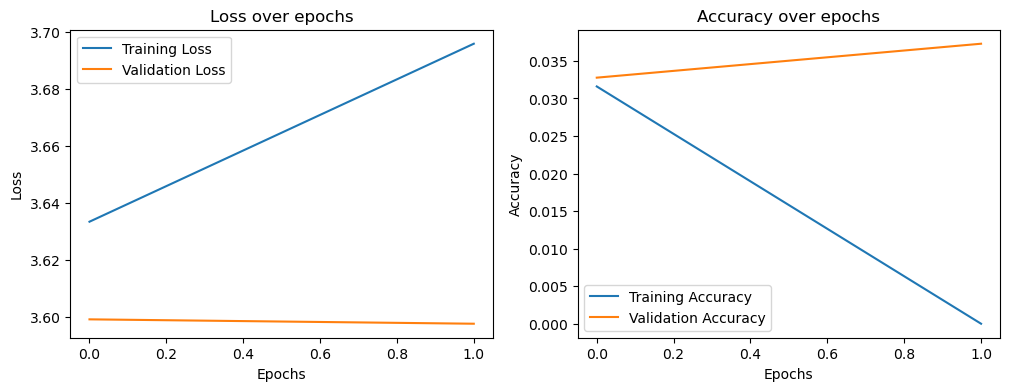

In [65]:
# Acceder a los datos de pérdida y precisión
loss = history_fine_tune.history['loss']
val_loss = history_fine_tune.history['val_loss']
accuracy = history_fine_tune.history['accuracy']
val_accuracy = history_fine_tune.history['val_accuracy']

# Graficar la pérdida del modelo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history['loss'], label='Training Loss')
plt.plot(history_fine_tune.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Graficar la precisión del modelo
plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history['accuracy'], label='Training Accuracy')
plt.plot(history_fine_tune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [66]:
epochs = list(range(1, 3))
data = {
    'Epoch': epochs,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

   Epoch  Trainning Loss  Validation Loss  Training Accuracy  \
0      1        3.633398         3.599088           0.031598   
1      2        3.695933         3.597551           0.000000   

   Validation  Accuracy  
0              0.032768  
1              0.037288  


In [67]:
# Accuracy final en entrenamiento
val_loss = history_fine_tune.history['val_loss'][-1]

In [68]:
print('Perdida final en Train:', history_fine_tune.history['loss'][-1])
print("Pérdida final en Validation:", history_fine_tune.history['val_loss'][-1])


print("Accuracy final en Train:", history_fine_tune.history['accuracy'][-1])
print("Accuracy final en Validation:", history_fine_tune.history['val_accuracy'][-1])

Perdida final en Train: 3.695932626724243
Pérdida final en Validation: 3.597550630569458
Accuracy final en Train: 0.0
Accuracy final en Validation: 0.03728813678026199


In [69]:
class_indices = train_generator.class_indices  # o test_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}
print(index_to_class)
with open("index_to_class_modelo11_balanceado_enfermedad.json", "w") as f:
    json.dump(index_to_class, f, indent=4, ensure_ascii=False)

{0: 'Fresa_Saludable_Saludable', 1: 'Coliflor_Enferma_Podredumbre blanda', 2: 'Papa_Enferma_Quemado de la papa', 3: 'Maíz_Saludable_Saludable', 4: 'Tomate_Enferma_Pinta en ojo de buey', 5: 'Papa_Enferma_Pudrición de la papa', 6: 'Tomate_Enferma_Pudrición de la papa', 7: 'Tomate_Enferma_Moteado del tomate', 8: 'Yuca_Enferma_Venas marrones de la yuca', 9: 'Tomate_Enferma_Hongo blanco del tomate', 10: 'Coliflor_Saludable_Saludable', 11: 'Manzana_Enferma_Hongo del manzano', 12: 'Tomate_Enferma_Puntos negros del tomate', 13: 'Yuca_Enferma_Pudrición de la yuca', 14: 'Yuca_Enferma_Manchas verdes en la yuca', 15: 'Tomate_Enferma_Quemado de la papa', 16: 'Maíz_Enferma_Moho rojo del maíz', 17: 'Pepino Cohombro_Saludable_Saludable', 18: 'Tomate_Saludable_Saludable', 19: 'Yuca_Saludable_Saludable', 20: 'Coliflor_Enferma_Pudrición del fruto', 21: 'Tomate_Enferma_Hojas enrolladas del tomate', 22: 'Manzana_Enferma_Costra de la manzana', 23: 'Maíz_Enferma_Quemazón del maíz', 24: 'Fríjol_Saludable_Salu

## 15. Testeo del Modelo

In [79]:
test.Planta_Condición_Enfermedad = test.Planta_Condición_Enfermedad.astype('str')

datagen = ImageDataGenerator(
    validation_split = 0.2,
    preprocessing_function = preprocess_leaf_image,
    rotation_range = 45,
    zoom_range = 0.2,
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = 'nearest',
    shear_range = 0.1,
    height_shift_range = 0.1,
    width_shift_range = 0.1
)

test_generator =  datagen.flow_from_dataframe(test,
                         directory = "Datos Finales",
                         subset = "training",
                         x_col = "image_id",
                         y_col = "Planta_Condición_Enfermedad",
                         target_size = (image_height,image_width),
                         batch_size = batch_size,
                         class_mode = "categorical")

Found 1654 validated image filenames belonging to 37 classes.


In [83]:
# -------------------------
# 1. Obtener predicciones completas para test
# -------------------------
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

111/111 ━━━━━━━━━━━━━━━━━━━━ 30s 272ms/step


<Figure size 20000x8000 with 0 Axes>

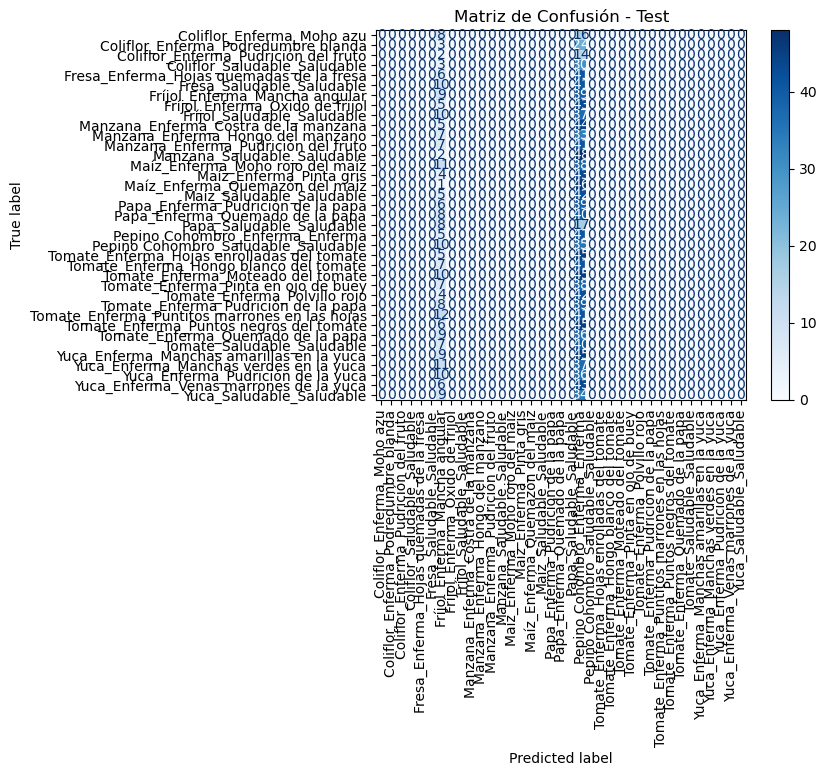

In [84]:
# -------------------------
# 2. Matriz de Confusión
# -------------------------
plt.figure(figsize=(200, 80))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap="Blues", xticks_rotation=90)
plt.title("Matriz de Confusión - Test")
plt.savefig("matriz_confusion_test_modelo_11.png", dpi=300, bbox_inches='tight')
plt.show()

In [85]:
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.0302


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step


ValueError: num must be an integer with 1 <= num <= 12, not 13

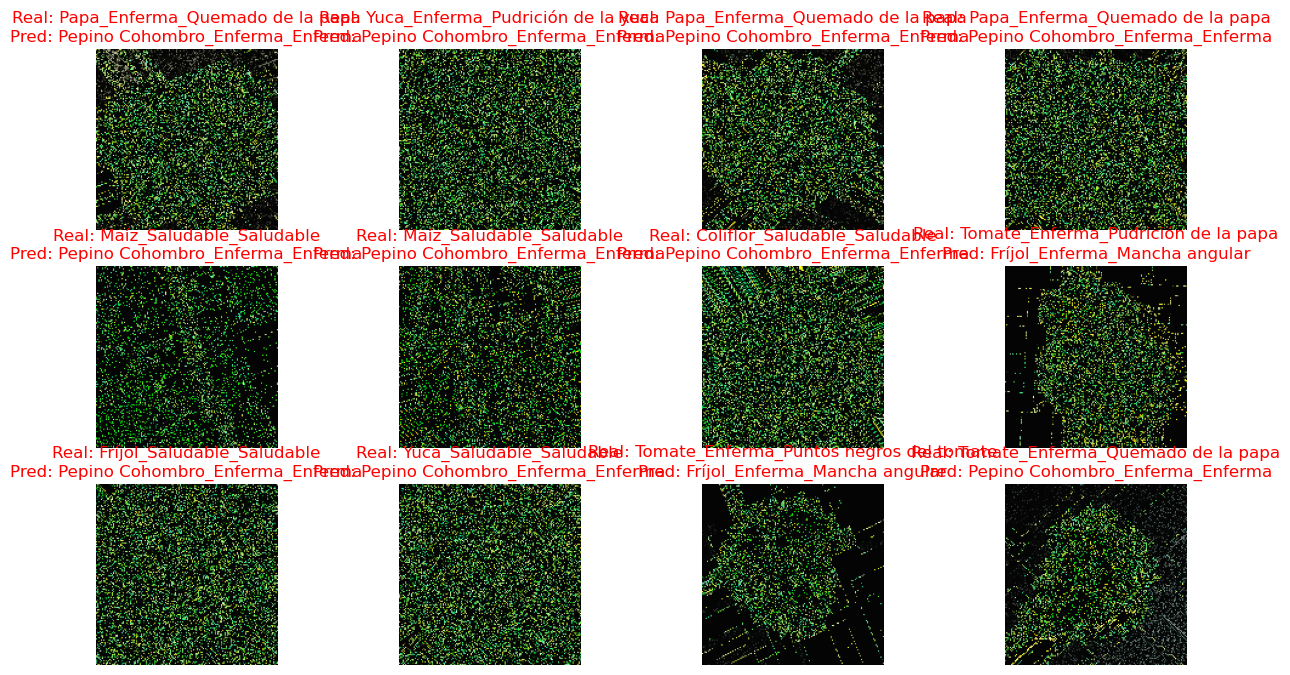

In [86]:
# Función para normalizar imágenes solo para visualización
def normalize_for_display(img):
    img_min = img.min()
    img_max = img.max()
    if img_max > 1.0 or img_min < 0.0:
        img = (img - img_min) / (img_max - img_min + 1e-7)
    return img

# Obtener nombres de clases
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Reiniciar el generador para empezar desde el principio
test_generator.reset()
x_batch, y_true_batch = next(test_generator)

# Obtener predicciones del modelo
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Número de imágenes a mostrar (máximo el tamaño del batch)
num_samples = x_batch.shape[0]

# Mostrar imágenes con etiquetas
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)
    img_to_show = normalize_for_display(x_batch[i])
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle("Muestreo de Predicciones vs. Etiquetas Reales", fontsize=16, y=1.02)
plt.show()

In [ ]:
# 3. Convertir etiquetas reales a one-hot
n_classes = y_pred_probs.shape[1]
y_true_onehot = to_categorical(y_true, num_classes=n_classes)

# 4. Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5. Obtener nombres de clase
class_names = list(test_generator.class_indices.keys())

# 6. Graficar curvas ROC
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por clase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

# AUC macro (promedio de clases, todas igual de importantes)
auc_macro = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')

# AUC micro (promedia sobre todas las instancias)
auc_micro = roc_auc_score(y_true_onehot, y_pred_probs, average='micro')

print(f"AUC Macro promedio: {auc_macro:.4f}")
print(f"AUC Micro promedio: {auc_micro:.4f}")


In [ ]:
# Asegúrate de tener esto:
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_generator.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Detalle por clase
class_names = list(test_generator.class_indices.keys())
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=class_names))


## 16. Guardar el modelo entrenado

In [ ]:
model.save('modelo_12_resnet50_fine_tuned_balanceado_enfermedades.h5')

In [ ]:
class_indices = train_generator.class_indices  # o test_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}